In [21]:
%pip install langchain langchain-openai langchain-community langgraph python-dotenv faiss-cpu pypdf langchain-text-splitters

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.2.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from dotenv import load_dotenv
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START
from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, BaseMessage
from langgraph.prebuilt import ToolNode, tools_condition

In [23]:
load_dotenv()

True

In [24]:
llm = ChatOpenAI(model="gpt-4o-mini")

In [25]:
loader = PyPDFLoader("intro-to-ml.pdf")
docs = loader.load()

In [26]:
splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200
)
chunks = splitter.split_documents(docs)

In [27]:
len(chunks)

973

In [28]:
embedddings = OpenAIEmbeddings(
    model="text-embedding-3-small"
)
vectore_store = FAISS.from_documents(chunks, embedddings)

In [29]:
vectore_store

In [30]:
retriever = vectore_store.as_retriever(
    search_type="similarity",
    search_kwargs={'k': 4}
)

In [39]:
@tool
def rag_tool(query: str):
    """
    Retrieve relevant information from the pdf document.
    Use this tool when the user asks factual / conceptual questions
    that might be answered from the stored documents.
    """

    result = retriever.invoke(query)

    return "\n\n".join(
        f"Source: {doc.metadata}\n{doc.page_content}" for doc in result
    )

    # context = "\n".join([doc.page_content for doc in result])
    # metadata = "\n".join([doc.metadata for doc in result])
    # return {
    #     "query": query,
    #     "context": context,
    #     "metadata": metadata
    # }

In [40]:
tools = [rag_tool]
llm_with_tools = llm.bind_tools(tools)

In [41]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [42]:
def chat_node(state: ChatState):

    messages = state["messages"]

    response = llm_with_tools.invoke(messages)

    return {
        "messages": [response]
    }

In [43]:
tool_node = ToolNode(tools)

In [44]:
graph = StateGraph(ChatState)

graph.add_node('chat_node', chat_node)
graph.add_node('tools', tool_node)

graph.add_edge(START, 'chat_node')
graph.add_conditional_edges('chat_node', tools_condition)
graph.add_edge('tools', 'chat_node')

chatbot = graph.compile()

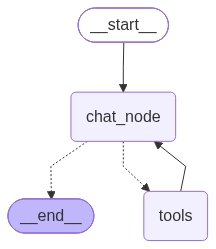

In [45]:
chatbot

In [46]:
result = chatbot.invoke(
    {
        "messages": [
            HumanMessage(
                content=(
                    "Using the pdf notes, explain how to find the ideal value of K in KNN"
                )
            )
        ]
    }
)

In [47]:
print(result['messages'][-1].content)

To find the ideal value of K in the K-Nearest Neighbors (KNN) algorithm, follow these steps:

1. **Understanding KNN**: KNN is a non-parametric algorithm used for classification (or regression) that classifies a data point based on how its neighbors are classified. The 'K' in KNN refers to the number of nearest neighbors to consider when making a prediction.

2. **Choosing the Right K**:
   - **Small Values of K**: A small value, like K=1, can make the model sensitive to noise in the data, which might lead to overfitting. This means that the model could perform well on training data but poorly on unseen test data.
   - **Larger Values of K**: A larger K can smooth out the decision boundary but may lead to underfitting, which occurs when the model is too generalized and misses essential patterns in the data.

3. **Using Cross-Validation**:
   - To determine the best value of K, use cross-validation. This involves splitting the dataset into training and validation sets multiple times and